# Scikit-learn

This notebook discusses some of the most important functions of scikit-learn

0. An end to end scikit-learn workflow
1. Getting the data ready
2. Choose the right estimator/algorithm for our problems
3. Fit the model/algorithm and use it to make predictions on our data
4. Evaluating a model
5. Improve a model
6. Save and load a trained model
7. Putting it all together!

So let's start!

# 0. An end to end scikit-learn workflow

In [96]:
# 1. getting the data ready
import numpy as np
import pandas as pd
heart_disease= pd.read_csv("087 heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [97]:
# Create X which is the features matrix
X = heart_disease.drop("target",axis=1) # drops the target column

# Create y which is the labels
y = heart_disease["target"]

In [98]:
# 2. Choose the right model and hyperparameters
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# We will keep the default hyperparameters
clf.get_params() # lists all the hyperparameters

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [99]:
# 3. Fit the model to the training data
from sklearn.model_selection import train_test_split

# we will split the data into training data and testing samples
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [100]:
clf.fit(X_train,y_train) #train the model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
y_preds= clf.predict(X_test)
y_preds

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1])

In [102]:
y_test

247    0
235    0
263    0
165    0
204    0
      ..
39     1
156    1
203    0
30     1
100    1
Name: target, Length: 76, dtype: int64

In [103]:
# 4.Evaluate the model
clf.score(X_train,y_train)

1.0

In [104]:
clf.score(X_test,y_test)

0.8157894736842105

In [105]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.87      0.79      0.82        42
           1       0.76      0.85      0.81        34

    accuracy                           0.82        76
   macro avg       0.82      0.82      0.82        76
weighted avg       0.82      0.82      0.82        76



In [106]:
confusion_matrix(y_test,y_preds)

array([[33,  9],
       [ 5, 29]])

In [107]:
accuracy_score(y_test,y_preds)

0.8157894736842105

In [108]:
# 5.Improving the model
# try different amounts of n_estimators
# Try different numbers of estimators (trees)... (no cross-validation)
np.random.seed(42)
for i in range(100, 200, 10):
    print(f"Trying model with {i} estimators...")
    model = RandomForestClassifier(n_estimators=i).fit(X_train, y_train)
    print(f"Model accuracy on test set: {model.score(X_test, y_test) * 100:.2f}%")
    print("")

Trying model with 100 estimators...
Model accuracy on test set: 82.89%

Trying model with 110 estimators...
Model accuracy on test set: 76.32%

Trying model with 120 estimators...
Model accuracy on test set: 81.58%

Trying model with 130 estimators...
Model accuracy on test set: 81.58%

Trying model with 140 estimators...
Model accuracy on test set: 78.95%

Trying model with 150 estimators...
Model accuracy on test set: 84.21%

Trying model with 160 estimators...
Model accuracy on test set: 77.63%

Trying model with 170 estimators...
Model accuracy on test set: 78.95%

Trying model with 180 estimators...
Model accuracy on test set: 84.21%

Trying model with 190 estimators...
Model accuracy on test set: 81.58%



In [109]:
# 6. Save a model and load it
import pickle

pickle.dump(clf, open("random-forest-classifier1.pkl", "wb"))

In [110]:
loaded_model= pickle.load(open("random-forest-classifier1.pkl","rb"))
loaded_model.score(X_test,y_test)

0.8157894736842105

In [111]:
# how to suppress the warnings that appear

# import warnings
# warnings.filterwarnings("ignore")

# Not to be used all the time

In [112]:
import sklearn
sklearn.show_versions()


System:
    python: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
executable: /home/aditya/miniconda3/envs/aiml/bin/python
   machine: Linux-6.19.9-arch1-1-x86_64-with-glibc2.43

Python dependencies:
      sklearn: 1.7.2
          pip: 26.0.1
   setuptools: 80.10.2
        numpy: 2.2.6
        scipy: 1.15.2
       Cython: None
       pandas: 2.3.3
   matplotlib: 3.10.8
       joblib: 1.5.3
threadpoolctl: 3.6.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: openblas
    num_threads: 12
         prefix: libopenblas
       filepath: /home/aditya/miniconda3/envs/aiml/lib/libopenblasp-r0.3.30.so
        version: 0.3.30
threading_layer: pthreads
   architecture: Haswell

       user_api: openmp
   internal_api: openmp
    num_threads: 12
         prefix: libgomp
       filepath: /home/aditya/miniconda3/envs/aiml/lib/libgomp.so.1.0.0
        version: None


# 1. Getting our data ready to be used with machine learning
    Three main things we have to do:
    1. Split the data into features and labels(usually 'X' and 'y')
    2. Filling (also called imputing) or disregarding missing values
    3. Converting non-numerical values to mumerical values(also called feature encoding)

In [113]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [114]:
X = heart_disease.drop("target",axis=1)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [115]:
y = heart_disease["target"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [116]:
# now splitting the data into training and test datasets
# from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

len(X),len(X_train),len(X_test)

(303, 242, 61)

### 1.1 Make sure that its all numerical

In [117]:
car_sales = pd.read_csv("car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [118]:
len(car_sales)

1000

In [119]:
X = car_sales.drop("Price",axis=1)
X.head()

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4
3,Toyota,White,154365,4
4,Nissan,Blue,181577,3


In [120]:
y = car_sales["Price"]
y.head()

0    15323
1    19943
2    28343
3    13434
4    14043
Name: Price, dtype: int64

In [121]:
# split the data 
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [122]:
# At first we need to convert the string to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features= ["Make", "Doors", "Colour"]
one_hot= OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                one_hot,
                                categorical_features)],
                                remainder="passthrough")

transformed_X= transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [123]:
pd.DataFrame(transformed_X).head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,154365.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,181577.0
5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,42652.0
6,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,163453.0
7,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,43120.0
8,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,130538.0
9,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,51029.0


In [124]:
dummies=pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummies.head()

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False


In [125]:
# now lets refit the model
np.random.seed(42)
X_train,X_test,y_train,y_test=train_test_split(transformed_X,y,test_size=0.2)

In [126]:
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor()

In [127]:
# train the model
reg.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
reg.score(X_test,y_test)

0.32392484470955096

## 1.2 what if we have missing values?

1.Fill them with some values(imputation)

2.Remove the samples with missing data altogether

In [129]:
car_sales_missing= pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [130]:
car_sales_missing.isna().sum() # this shows how many missing items each has

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [131]:
X = car_sales_missing.drop("Price",axis=1)
X.head()

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431.0,4.0
1,BMW,Blue,192714.0,5.0
2,Honda,White,84714.0,4.0
3,Toyota,White,154365.0,4.0
4,Nissan,Blue,181577.0,3.0


In [132]:
y = car_sales_missing["Price"]
y.head()

0    15323.0
1    19943.0
2    28343.0
3    13434.0
4    14043.0
Name: Price, dtype: float64

In [133]:
categorical_features= ["Make", "Doors", "Colour"]
one_hot= OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                one_hot,
                                categorical_features)],
                                remainder="passthrough")

transformed_X= transformer.fit_transform(X) # this does not give an error but we should fill the missing data (NaN)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4000 stored elements and shape (1000, 16)>

### Option 1: Fill the missing data with pandas

In [134]:
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("missing")
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("missing")
car_sales_missing["Odometer (KM)"] = car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean())
car_sales_missing["Doors"]=car_sales_missing["Doors"].fillna(4)

In [135]:
# Remove rows with missing price value
car_sales_missing=car_sales_missing.dropna()

In [136]:
car_sales_missing.isna().sum() # we can see that there are no missing values

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [137]:
X = car_sales_missing.drop("Price",axis=1)
X.head()

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431.0,4.0
1,BMW,Blue,192714.0,5.0
2,Honda,White,84714.0,4.0
3,Toyota,White,154365.0,4.0
4,Nissan,Blue,181577.0,3.0


In [138]:
y = car_sales_missing["Price"]
y.head()

0    15323.0
1    19943.0
2    28343.0
3    13434.0
4    14043.0
Name: Price, dtype: float64

In [139]:
categorical_features= ["Make", "Doors", "Colour"]
one_hot= OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                one_hot,
                                categorical_features)],
                                remainder="passthrough")

transformed_X= transformer.fit_transform(car_sales_missing) # this does not give an error(from pandas 3.0) but we should fill the missing data (NaN)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

### 2. Filling up missing data using sklearn

In [140]:
car_sales_missing= pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [141]:
car_sales_missing= car_sales_missing.dropna(subset=["Price"]) # removing those rows with missing price

In [142]:
X = car_sales_missing.drop("Price",axis=1)
y = car_sales_missing["Price"]

In [143]:
# Fill missing values with sklearn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Fill missing categirical using "missing" and numerical using mean.
cat_imputer= SimpleImputer(strategy="constant", fill_value="missing")
door_imputer= SimpleImputer(strategy="constant", fill_value=4)
num_imputer= SimpleImputer(strategy="mean")

# Define columns
cat_features= ["Make","Colour"]
door_feature= ["Doors"]
num_features= ["Odometer (KM)"]

# Create the imputer
imputer= ColumnTransformer(
    [
        ("cat_imputer",cat_imputer,cat_features),
        ("door_imputer",door_imputer,door_feature),
        ("num_imputer",num_imputer,num_features)
    ]
)

# Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

# 2. Choosing the right estimator/algorithm for our problem
        Sklearn uses estimator as another term for machine learning algorithm

        1. Classification - predicting whether a sample is one thing or another
        2. Regression - predicting a number

### 2.1 Picking a machine learning model for a regression problem

In [144]:
# import boston housing dataset - this is a sklearn inbuilt dataset
# boston housing dataset was removed so instead we use California housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [145]:
housing_df = pd.DataFrame(housing["data"], columns= housing["feature_names"])
housing_df["target"]=pd.Series(housing["target"])
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [146]:
# Lets try the Ridge Rigression model
from sklearn.linear_model import Ridge
np.random.seed(42)

# Create the data
X = housing_df.drop("target",axis=1)
y = housing_df["target"]

# Split the data into train and test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Instantiate a model
model = Ridge()

# train
model.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [147]:
model.score(X_test,y_test)

0.5758549611440126

## The cheatsheet
<img src="./ml_map.svg" height=700px width=850px/>

##### Our previous model's score was not that good so we follow the cheatsheet and see which model we can use to get a better result

In [148]:
# Import random forest regressor
from sklearn.ensemble import RandomForestRegressor

# set a seed
np.random.seed(42)

# Get the data
X = housing_df.drop(["target"],axis=1)
y = housing_df["target"]

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Make an instance of the model
rf = RandomForestRegressor()

# Train the model
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [149]:
# check the score 
rf.score(X_test,y_test)

0.8066196804802649

## Choosing an estimator for  a classification problem

In [150]:
# We will choose a data set for a classification problem
heart_disease = pd.read_csv("087 heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [151]:
# Consulting the map and it says to try linearSVC
from sklearn.svm import LinearSVC

# set a seed
np.random.seed(42)

# Get the data
X = heart_disease.drop(["target"],axis=1)
y = heart_disease["target"]

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Instantiate the model
clf = LinearSVC()

# Train the model
clf.fit(X_train,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [152]:
clf.score(X_test,y_test)

0.8688524590163934

In [153]:
# Now lets try with Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# set a seed
np.random.seed(42)

# Get the data
X = heart_disease.drop(["target"],axis=1)
y = heart_disease["target"]

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Instantiate the model
clf = RandomForestClassifier()

# Train the model
clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [154]:
clf.score(X_test,y_test)

0.8524590163934426

### Tidbit: 
    1. If you have structured data(data in a proper table) use ensemble methods
    2. If you have unstructured data use deep learning or transfer learning

## 3. Fit the model on our data and use it to make predictions

### 3.1 Fitting the model with our data 

* `X` = features ,feature variable ,data
* `y` = labels, targets, target variables

In [155]:
# Now lets try with Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# set a seed
np.random.seed(42)

# Get the data
X = heart_disease.drop(["target"],axis=1)
y = heart_disease["target"]

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Instantiate the model
clf = RandomForestClassifier()

# Train the model
clf.fit(X_train,y_train) # train the machine learning model to find patterns in the dataset

clf.score(X_test,y_test) # Using the patterns the model has found and determining the result

0.8524590163934426

### 3.2 Making predictions with `predict_proba()`

In [156]:
# predict_proba() returns probabilities of a classification
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [157]:
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [158]:
# Trying to see how predict() would be like for a regression model
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [159]:
# Spearating the features and labels(X and y)
X = housing_df.drop("target",axis=1)
y = housing_df["target"]

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Instantiate the model
reg = RandomForestRegressor()

# Train the model using the train data
reg.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [160]:
y_preds=reg.predict(X_test)
y_preds

array([1.7471   , 1.23883  , 2.3498401, ..., 2.8758201, 1.60219  ,
       1.84951  ], shape=(4128,))

In [161]:
np.array(y_test)

array([1.339, 1.291, 1.996, ..., 2.304, 1.99 , 1.676], shape=(4128,))

In [162]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.3268376173691862

## 4. Evaluating a machine learning model

There are 3 ways to evaluate a machine learning model:

1. Estimator `score` method
2. The `scoring` parameter
3. Problem specific metric functions

#### 4.1 Evaluating model using `score` method:

In [163]:
# Now lets try with Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# set a seed
np.random.seed(42)

# Get the data
X = heart_disease.drop(["target"],axis=1)
y = heart_disease["target"]

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Instantiate the model
clf = RandomForestClassifier()

# Train the model
clf.fit(X_train,y_train)

# Score
clf.score(X_test,y_test)

0.8524590163934426

Every model has its different kind of evaluation metric, for instance:
regression models use -> use coefficient of determination
classification models use -> use accuracy

### Evaluating a model using the `scoring` parametrer

#### Cross Validation

Cross-validation (in scikit-learn) is a technique to evaluate a model more reliably by splitting your dataset into multiple parts.

⚡ Core idea
- Split data into k folds (e.g., 5)
- Train on k-1 folds, test on the remaining fold
- Repeat this k times, each fold used once as test
- Take the average score

In [164]:
# Using cross validation
from sklearn.model_selection import cross_val_score

cv5=cross_val_score(clf, X, y) # by default cv = 5 
cv5

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [165]:
cv10=cross_val_score(clf, X, y,cv=10)
cv10

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

In [166]:
clf_single= clf.score(X_test,y_test)

clf_single,np.mean(cv5),np.mean(cv10) # these are progessively more accurate on how accurate our model is

(0.8524590163934426,
 np.float64(0.811639344262295),
 np.float64(0.8280645161290323))

In [167]:
# Scoring parameter is by default set to none
# so it uses the default scoring paramter like for example for classifier = accuracy

### 4.2.1 Classification model evaluation metrics

- Accuracy
- Area under ROC curve
- Confusion matrix
- Classification report

#### Accuracy

In [168]:
cross_val_scores = cross_val_score(clf,X,y,cv=5)
cross_val_scores #by default the metric for classification is accuracy
acc = np.mean(cross_val_scores)

In [169]:
print(f"The accuracy of our cross validated classification model is {acc*100:.2f}%")

The accuracy of our cross validated classification model is 82.81%


#### Area under the reciever operating characteristic curve(AUC/ROC)

- Area under curve(AUC)
- ROC curve

ROC are a comparison of a models true positive rate(tpr) vs a models false positive rate(fpr)

- True positive is when our model predicts `1` but the truth is `1`
- False positive is when out model predicts `1` but the truth is `0`
- True negative is when out model predicts `0` but the truth is `0`
- False negative is when out model predicts `0` but the truth is `1`

In [170]:
from sklearn.metrics import roc_curve

# Fit the classifier
clf.fit(X_train,y_train)

# Make predictions with probabilities
y_probs= clf.predict_proba(X_test)

y_probs[:10] # we want only the positive class(1) 

array([[0.9 , 0.1 ],
       [0.31, 0.69],
       [0.45, 0.55],
       [0.85, 0.15],
       [0.21, 0.79],
       [0.2 , 0.8 ],
       [0.32, 0.68],
       [0.95, 0.05],
       [0.98, 0.02],
       [0.49, 0.51]])

In [171]:
y_probs_positive = y_probs[:,1]
y_probs_positive[:10]

array([0.1 , 0.69, 0.55, 0.15, 0.79, 0.8 , 0.68, 0.05, 0.02, 0.51])

### ROC Curve & Thresholds — Quick Notes

#### 🔹 What is a threshold?

A **threshold** is the cutoff used to convert predicted probabilities into class labels:

* If `prob >= threshold` → predict **1 (positive)**
* If `prob < threshold` → predict **0 (negative)**

Example:

```python
if prob >= 0.5:
    y_pred = 1
else:
    y_pred = 0
```

---

#### 🔹 What does `roc_curve()` do?

```python
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
```

It:

1. Takes true labels (`y_test`)
2. Takes predicted probabilities (`y_probs`)
3. Tries **multiple thresholds**
4. Computes:

   * **TPR (True Positive Rate / Recall)**
   * **FPR (False Positive Rate)**

---

#### 🔹 What does “all thresholds” mean?

It does **NOT** try every decimal number.

Instead:

> It uses **all unique probability values** from `y_probs` as thresholds.

Example:

```python
y_probs = [0.95, 0.87, 0.76, 0.60]
```

Thresholds used:

```text
[inf, 0.95, 0.87, 0.76, 0.60, 0.0]
```

---

#### 🔹 Why only these values?

Because:

> Predictions change **only when the threshold crosses a probability value**.

Between two values (e.g., 0.80 and 0.77), predictions remain the same → no need to test both.

---

#### 🔹 How ROC curve is formed

For each threshold:

1. Convert probabilities → predictions
2. Compute:

   * TPR = TP / (TP + FN)
   * FPR = FP / (FP + TN)
3. Plot point (FPR, TPR)

All points together form the **ROC curve**.

---

#### 🔹 Extreme cases

* Threshold = `∞` → all predictions = 0 → (FPR=0, TPR=0)
* Threshold = `0` → all predictions = 1 → (FPR=1, TPR=1)

---

#### 🔹 Key intuition

> ROC shows how model performance changes as you vary how strict the decision threshold is.

---

#### 🔹 One-line summary

> ROC = evaluate model performance across all meaningful thresholds (cutoffs).


In [172]:
# Calculate fpr,tpr and thresholds
fpr,tpr,thresholds = roc_curve(y_test,y_probs_positive)

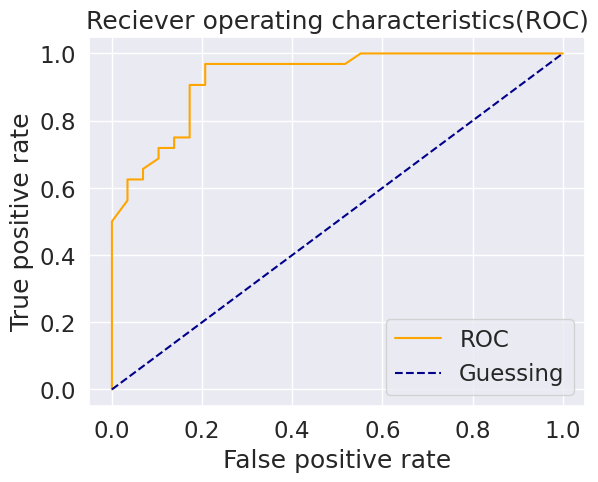

In [173]:
# Creating a function to plot the ROC curve
import matplotlib.pyplot as plt

def plot_roc_curve(fpr,tpr):
    """
    Plots the ROC curve given the false
    positive and and the true positive rate
    of a model
    """
    # Plot the roc curve
    plt.plot(fpr,tpr, color="orange", label= "ROC")
    # Plot a line with no predictive power
    plt.plot([0,1],[0,1] ,color="darkblue", linestyle="--",label="Guessing")
    # this draws a line between (0,0) to (1,1)

    # Customize the plot
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Reciever operating characteristics(ROC)")
    plt.legend()
    plt.show()

plot_roc_curve(fpr,tpr)

In [174]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_probs_positive)

0.927801724137931

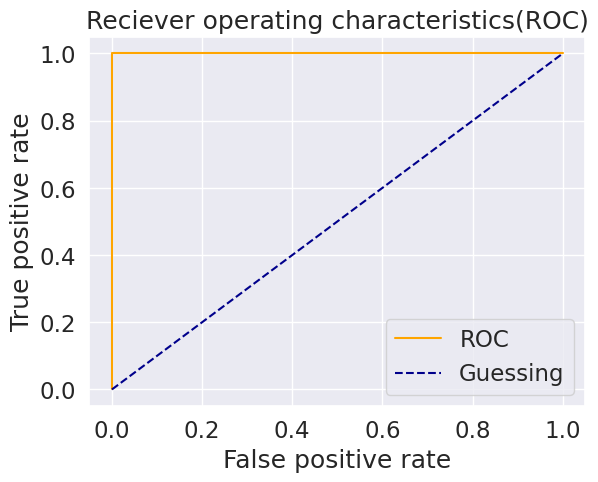

In [175]:
# plotting the perfect roc curve
fpr,tpr,thresholds = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)

In [176]:
roc_auc_score(y_test,y_test)

1.0

#### Confusion matrix

A confusion matrix is a easy way to compare the labels a model predicts and the actual labels it was supposed to predict

In essence giving the idea how much our model is getting confused

In [177]:
from sklearn.metrics import confusion_matrix

y_preds= clf.predict(X_test)

confusion_matrix(y_preds,y_test)

array([[24,  3],
       [ 5, 29]])

In [178]:
pd.crosstab(y_test,
            y_preds,
            rownames=["Actual labels"],
            colnames=["Predicted labels"])


# These are essentially this:

# True positive is when our model predicts 1 but the truth is 1 --> 29
# False positive is when out model predicts 1 but the truth is 0 --> 5
# True negative is when out model predicts 0 but the truth is 0 --> 24
# False negative is when out model predicts 0 but the truth is 1 --> 3

Predicted labels,0,1
Actual labels,,
0,24,5
1,3,29


<Axes: >

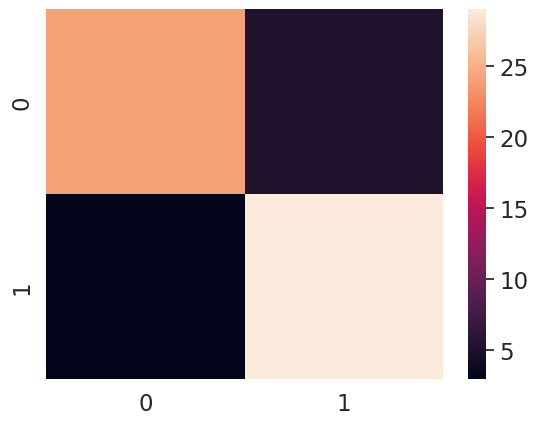

In [179]:
# Visualizing the confusion matrix using seaborn

import seaborn as sns

#set the scale
sns.set(font_scale=1.5)

conf_mat= confusion_matrix(y_test,y_preds)

sns.heatmap(conf_mat)

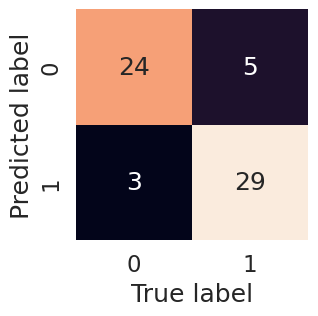

In [180]:
def plot_conf_mat(conf_mat):
    '''
    Plots a confusion matrix using seaborn's heatmap
    '''

    fig,ax = plt.subplots(figsize=(3,3))

    ax = sns.heatmap(conf_mat,
                    annot=True, # Annotate the conf mat info
                    cbar=False)

    plt.xlabel("True label")
    plt.ylabel("Predicted label")

plot_conf_mat(conf_mat)

In [181]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



### Classification Metrics — Meaning + When to Use

* **Precision** → Out of all predicted positives, how many were actually correct.
  👉 Use when **false positives are costly** (e.g., spam detection, fraud alerts where false alarms are bad).

* **Recall** → Out of all actual positives, how many the model correctly identified.
  👉 Use when **false negatives are costly** (e.g., disease detection, missing a positive case is dangerous).

* **F1-score** → Balance between precision and recall.
  👉 Use when you need a **trade-off between false positives and false negatives**, especially with imbalanced data.

* **Support** → Number of actual samples for each class.
  👉 Use to **understand class distribution** (helps detect imbalance issues).

* **Accuracy** → Overall percentage of correct predictions.
  👉 Use when **classes are balanced** and all errors are equally important.

* **Macro avg** → Average metric treating all classes equally.
  👉 Use when you want to **evaluate performance per class equally**, even if dataset is imbalanced.

* **Weighted avg** → Average metric weighted by class size.
  👉 Use when dataset is **imbalanced and you want a realistic overall score**.


## Regression model evaluation metrics
 1. R^2(r-squared) or coefficient of determination
 2. Mean absolute error
 3. Mean squared error

### R2

Interpretation:

    : Perfect prediction, model fits the data perfectly.
    : The model performs no better than a horizontal line representing the mean of the data.
    Negative
    : This indicates the model fits the data worse than simply predicting the mean, likely due to an inappropriate model or nonlinear data.

* **R² score** tells how well a regression model explains the variation in the data.
* It compares your model with a simple baseline that predicts the average value.
* Value ranges from 1 (perfect) to 0 (no improvement), and can be negative if the model is worse.


In [182]:
from sklearn.ensemble import RandomForestRegressor
housing = fetch_california_housing()

housing_df = pd.DataFrame(housing["data"], columns= housing["feature_names"])
housing_df["target"]=pd.Series(housing["target"])
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [183]:
X = housing_df.drop("target",axis=1)
y = housing_df["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
model = RandomForestRegressor()

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [184]:
model.score(X_test,y_test)

0.8075363537670597

In [185]:
from sklearn.metrics import r2_score

# Fill an array with the mean of y_test
y_test_mean = np.full(len(y_test),y_test.mean())

In [186]:
y_test_mean

array([2.0604392, 2.0604392, 2.0604392, ..., 2.0604392, 2.0604392,
       2.0604392], shape=(4128,))

In [187]:
r2_score(y_test,y_test_mean)

0.0

In [188]:
r2_score(y_test,y_test)

1.0

### Mean absolute error(MAE)

* **Mean Absolute Error (MAE)** measures the average difference between predicted values and actual values.
* It takes the absolute value of errors, so all mistakes are treated equally (no negatives).
* Lower MAE means better model performance.


In [189]:
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(X_test)
mae = mean_absolute_error(y_test, y_preds)
mae

0.32855489123062037

In [190]:
df = pd.DataFrame(data={"actual values":y_test,
                        "predicted values": y_preds})
df["differences"] = df["predicted values"] - df["actual values"]
df

,actual values,predicted values,differences
10712,1.90900,1.902180,-0.006820
17583,2.92500,2.498530,-0.426470
6700,4.90400,3.974001,-0.929999
4985,1.29100,1.172720,-0.118280
15015,1.44700,1.611280,0.164280
...,...,...,...
6736,5.00001,4.999870,-0.000140
8694,2.48600,2.340040,-0.145960
12551,1.91900,1.932140,0.013140
8270,2.66300,2.193860,-0.469140


**Mean Squared error**

In [191]:
# Mean Squared error 
from sklearn.metrics import mean_squared_error

y_preds = model.predict(X_test)
mse = mean_squared_error(y_test,y_preds)
mse

0.2585073641171409